# Sentiment Analysis on Large Indonesian Product Review Dataset
## Replication + Improvements for Higher-Impact Journal Submission

**Reference paper:**  
Romadhony, A., Al Faraby, S., Rismala, R., Wisesti, U.N., & Arifianto, A. (2024).  
*Sentiment Analysis on a Large Indonesian Product Review Dataset.*  
Journal of Information Systems Engineering and Business Intelligence, 10(1), 167–178.  
DOI: http://dx.doi.org/10.20473/jisebi.10.1.167-178

---

## Structure of this Notebook

| Section | Description |
|---------|-------------|
| **1. Setup & Dataset Characteristics** | Reproduce dataset statistics from paper (FDReview: 702,634 reviews) |
| **2. EDA** | Rating distribution, text length analysis, n-gram analysis |
| **3. Preprocessing** | Casefolding, normalization, stopword removal |
| **4. Baseline Replication** | MNB + SVM with BoW/TF-IDF (unigram, bigram, trigram) |
| **5. Improvement I** | Complement Naïve Bayes + Logistic Regression |
| **6. Improvement II** | Class imbalance handling (SMOTE-text via oversampling) |
| **7. Improvement III** | Ensemble & Stacking methods |
| **8. Improvement IV** | Feature engineering: char n-grams + subword features |
| **9. Improvement V** | Calibrated classifiers + threshold optimization |
| **10. Full Results Comparison** | All models, all metrics, publication-ready tables & plots |
| **11. Error Analysis** | Where models fail — confusion matrices + misclassified examples |
| **12. Discussion & Conclusion** | Gap analysis vs paper, suggested next steps (IndoBERT, etc.) |

---
## Section 1 — Setup & Dataset Characteristics

This notebook uses the **real FDReview dataset** (pre-split into train and test sets to prevent data leakage). The characteristics of the loaded dataset are as follows:

### 1. Total Statistics
- **Total reviews:** 702,634
- **Class distribution (combined):**
    - **Positive (`pos`):** 491,316 reviews (originally ratings 4 & 5)
    - **Neutral (`neu`):** 128,945 reviews (originally rating 3)
    - **Negative (`neg`):** 82,373 reviews (originally ratings 1 & 2)

### 2. Dataset Split
| Subset | Positive | Neutral | Negative | **Total** |
|--------|----------|---------|----------|-----------|
| **Train** | 393,053 | 103,156 | 65,898 | **562,107** |
| **Test** | 98,263 | 25,789 | 16,475 | **140,527** |


### 4. Small Datasets for Comparison
In addition to the large dataset, we use two 12,000-review subsets for sensitivity analysis:
- **Small-Unbalanced:** Follows the natural distribution (~70% positive).
- **Small-Balanced:** Balanced positive and negative classes (4,800 each) with 2,400 neutral reviews.
### 3. Average Text Lengths (Actual)
- **Positive:** ~363 characters
- **Neutral:** ~342 characters
- **Negative:** ~334 characters

These values closely match the statistics reported in the reference paper by Romadhony et al. (2024).

In [39]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()
import re
import string
import random
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.utils import resample
from scipy.sparse import hstack, vstack

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6']
CLR = {'negative': '#e74c3c', 'neutral': '#f39c12', 'positive': '#27ae60'}

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

PATH = 'dataset/sentiment_classification'
PATH_IMG = 'figures/sentiment'

print("✅ Libraries loaded successfully")



✅ Libraries loaded successfully


In [ ]:
# ═══════════════════════════════════════════════════════════
# DATA LOADING (REAL FDReview Dataset - Pre-split for No Bleeding)
# ═══════════════════════════════════════════════════════════
import json

def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line.strip()))
    df = pd.DataFrame(data)
    if 'review_class' in df.columns:
        # Check if values are numeric
        try:
            # Try to convert to numeric, if it fails or has NaNs, it might be strings
            numeric_check = pd.to_numeric(df['review_class'], errors='coerce')
            if numeric_check.notnull().all():
                df['rating'] = numeric_check.astype(int)
                df['sentiment'] = df['rating'].apply(lambda x: 'positive' if x >= 4 else ('neutral' if x == 3 else 'negative'))
            else:
                raise ValueError("Contains non-numeric strings")
        except:
            # Handle string labels 'pos', 'neu', 'neg'
            sentiment_map = {'pos': 'positive', 'neu': 'neutral', 'neg': 'negative'}
            rating_map = {'pos': 5, 'neu': 3, 'neg': 1}
            df['sentiment'] = df['review_class'].map(sentiment_map)
            df['rating'] = df['review_class'].map(rating_map)
            
    if 'product_category' not in df.columns:
        df['product_category'] = 'Unknown'
    return df


print("Loading split datasets to prevent data leakage...")

df_large_train = load_jsonl(f"{PATH}/all_dataset_train.json")
df_large_test = load_jsonl(f"{PATH}/all_dataset_test.json")
df_large = (df_large_train, df_large_test)  # Store as tuple

df_small_unbal = (load_jsonl(f"{PATH}/small_review_imbal_train.json"),
                  load_jsonl(f"{PATH}/small_review_imbal_test.json"))

df_small_bal = (load_jsonl(f"{PATH}/small_review_bal_train.json"),
                load_jsonl(f"{PATH}/small_review_bal_test.json"))

print(f"Large:   {len(df_large_train):,} train | {len(df_large_test):,} test")
print(f"Small Unbalanced: {len(df_small_unbal[0]):,} train | {len(df_small_unbal[1]):,} test")
print(f"Small Balanced:   {len(df_small_bal[0]):,} train | {len(df_small_bal[1]):,} test")

print("\nRating distribution (large train set):")
print(df_large_train['rating'].value_counts().sort_index())

Loading split datasets to prevent data leakage...
Large:   562,107 train | 140,527 test
Small Unbalanced: 12,000 train | 3,000 test
Small Balanced:   12,000 train | 3,000 test

Rating distribution (large train set):
rating
1     65898
3    103156
5    393053
Name: count, dtype: int64


In [46]:
# Function to display sentiment distribution
def show_sentiment_distribution(train_df, test_df, name="Dataset"):
    print(f"📊 Sentiment Distribution for {name}:")
    
    # Calculate counts
    train_counts = train_df['sentiment'].value_counts()
    test_counts = test_df['sentiment'].value_counts()
    
    # Create a summary DataFrame for display
    dist_df = pd.DataFrame({
        'Train Count': train_counts,
        'Train %': (train_counts / len(train_df) * 100).round(2),
        'Test Count': test_counts,
        'Test %': (test_counts / len(test_df) * 100).round(2)
    }).fillna(0)
    
    # Ensure correct order
    order = ['positive', 'neutral', 'negative']
    dist_df = dist_df.reindex([o for o in order if o in dist_df.index])
    
    print(dist_df)
    print("-" * 50)

# Display for all dataset versions
show_sentiment_distribution(df_large_train, df_large_test, "Large Dataset")
show_sentiment_distribution(df_small_unbal[0], df_small_unbal[1], "Small Unbalanced")
show_sentiment_distribution(df_small_bal[0], df_small_bal[1], "Small Balanced")


📊 Sentiment Distribution for Large Dataset:
           Train Count  Train %  Test Count  Test %
sentiment                                          
positive        393053    69.92       98263   69.92
neutral         103156    18.35       25789   18.35
negative         65898    11.72       16475   11.72
--------------------------------------------------
📊 Sentiment Distribution for Small Unbalanced:
           Train Count  Train %  Test Count  Test %
sentiment                                          
positive          8400     70.0        2100    70.0
neutral           2160     18.0         540    18.0
negative          1440     12.0         360    12.0
--------------------------------------------------
📊 Sentiment Distribution for Small Balanced:
           Train Count  Train %  Test Count  Test %
sentiment                                          
positive          4800     40.0        1200    40.0
neutral           2400     20.0         600    20.0
negative          4800     40.0   

In [60]:
# 1. Combine all training sets
df_combined_train = pd.concat([
    df_large_train, 
    df_small_unbal[0], 
    df_small_bal[0]
], ignore_index=True)

# 2. Combine all test sets
df_combined_test = pd.concat([
    df_large_test, 
    df_small_unbal[1], 
    df_small_bal[1]
], ignore_index=True)

# 3. Display the combined distribution
show_sentiment_distribution(df_combined_train, df_combined_test, "TOTAL COMBINED (Large + Small Unbal + Small Bal)")

# (Optional) Display total summary as a single table
grand_total = len(df_combined_train) + len(df_combined_test)

total_positive = int(df_grand_total[df_grand_total['sentiment'] == 'positive'].shape[0])
total_neutral  = int(df_grand_total[df_grand_total['sentiment'] == 'neutral'].shape[0])
total_negative = int(df_grand_total[df_grand_total['sentiment'] == 'negative'].shape[0])

print("\n📊 Total Observations Summary:")
print(f"Total Combined Training: {len(df_combined_train):,}")
print(f"Total Combined Testing:  {len(df_combined_test):,}")
print(f"Grand Total:             {grand_total:,}")


📊 Sentiment Distribution for TOTAL COMBINED (Large + Small Unbal + Small Bal):
           Train Count  Train %  Test Count  Test %
sentiment                                          
positive        406253    69.31      101563   69.31
neutral         107716    18.38       26929   18.38
negative         72138    12.31       18035   12.31
--------------------------------------------------

📊 Total Observations Summary:
Total Combined Training: 586,107
Total Combined Testing:  146,527
Grand Total:             732,634


In [80]:
# 1. Calculate length for each review in the combined dataset
# (Assumes the column name is 'review_text')
df_grand_total['text_length'] = df_grand_total['review_text'].str.len()

# 2. Group by sentiment and calculate the average
avg_lengths = df_grand_total.groupby('sentiment')['text_length'].mean().round(2)

# 3. Display as a clean summary
avg_summary = pd.DataFrame({
    'Average Character Length': avg_lengths
})

# Ensure standard order
order = ['positive', 'neutral', 'negative']
avg_summary = avg_summary.reindex([o for o in order if o in avg_summary.index])

print("📏 AVERAGE TEXT LENGTH PER CLASS")
print(avg_summary)

# Optional: Store in separate variables if needed
avg_pos_len = avg_lengths.get('positive', 0)
avg_neu_len = avg_lengths.get('neutral', 0)
avg_neg_len = avg_lengths.get('negative', 0)


📏 AVERAGE TEXT LENGTH PER CLASS
           Average Character Length
sentiment                          
positive                     364.76
neutral                      341.51
negative                     335.02


In [109]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_unigrams(df, sentiment_label, top_n=10):
    # 1. Filter by class and ensure we have actual text
    text_data = df[df['sentiment'] == sentiment_label]['review_text'].dropna()
    
    # 2. Safety check: If no data found for this class, return an empty list
    if text_data.empty:
        print(f"⚠️ Warning: No data found for class '{sentiment_label}'")
        return []
    try:
        # 3. Use CountVectorizer with a more flexible token pattern 
        # (token_pattern=r"(?u)\b\w+\b" allows 1-character words)
        vec = CountVectorizer(
            ngram_range=(1, 1), 
            max_features=1000,
            token_pattern=r"(?u)\b\w+\b" 
        ).fit(text_data)
        
        bag_of_words = vec.transform(text_data)
        sum_words = bag_of_words.sum(axis=0) 
        
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
        
        return words_freq[:top_n]
    
    except ValueError:
        # 4. Handle cases where text exists but contains no valid tokens
        print(f"⚠️ Warning: Class '{sentiment_label}' contains text but no valid words were found.")
        return []

# Re-run the population loop
top_words = {'positive': [], 'neutral': [], 'negative': []}
for sentiment in top_words.keys():
    raw_list = get_top_unigrams(df_grand_total, sentiment, top_n=10)
    top_words[sentiment] = [word for word, freq in raw_list]
print("✅ Variable 'top_words' updated.")



✅ Variable 'top_words' updated.


---
## Section 2 — Exploratory Data Analysis (EDA)

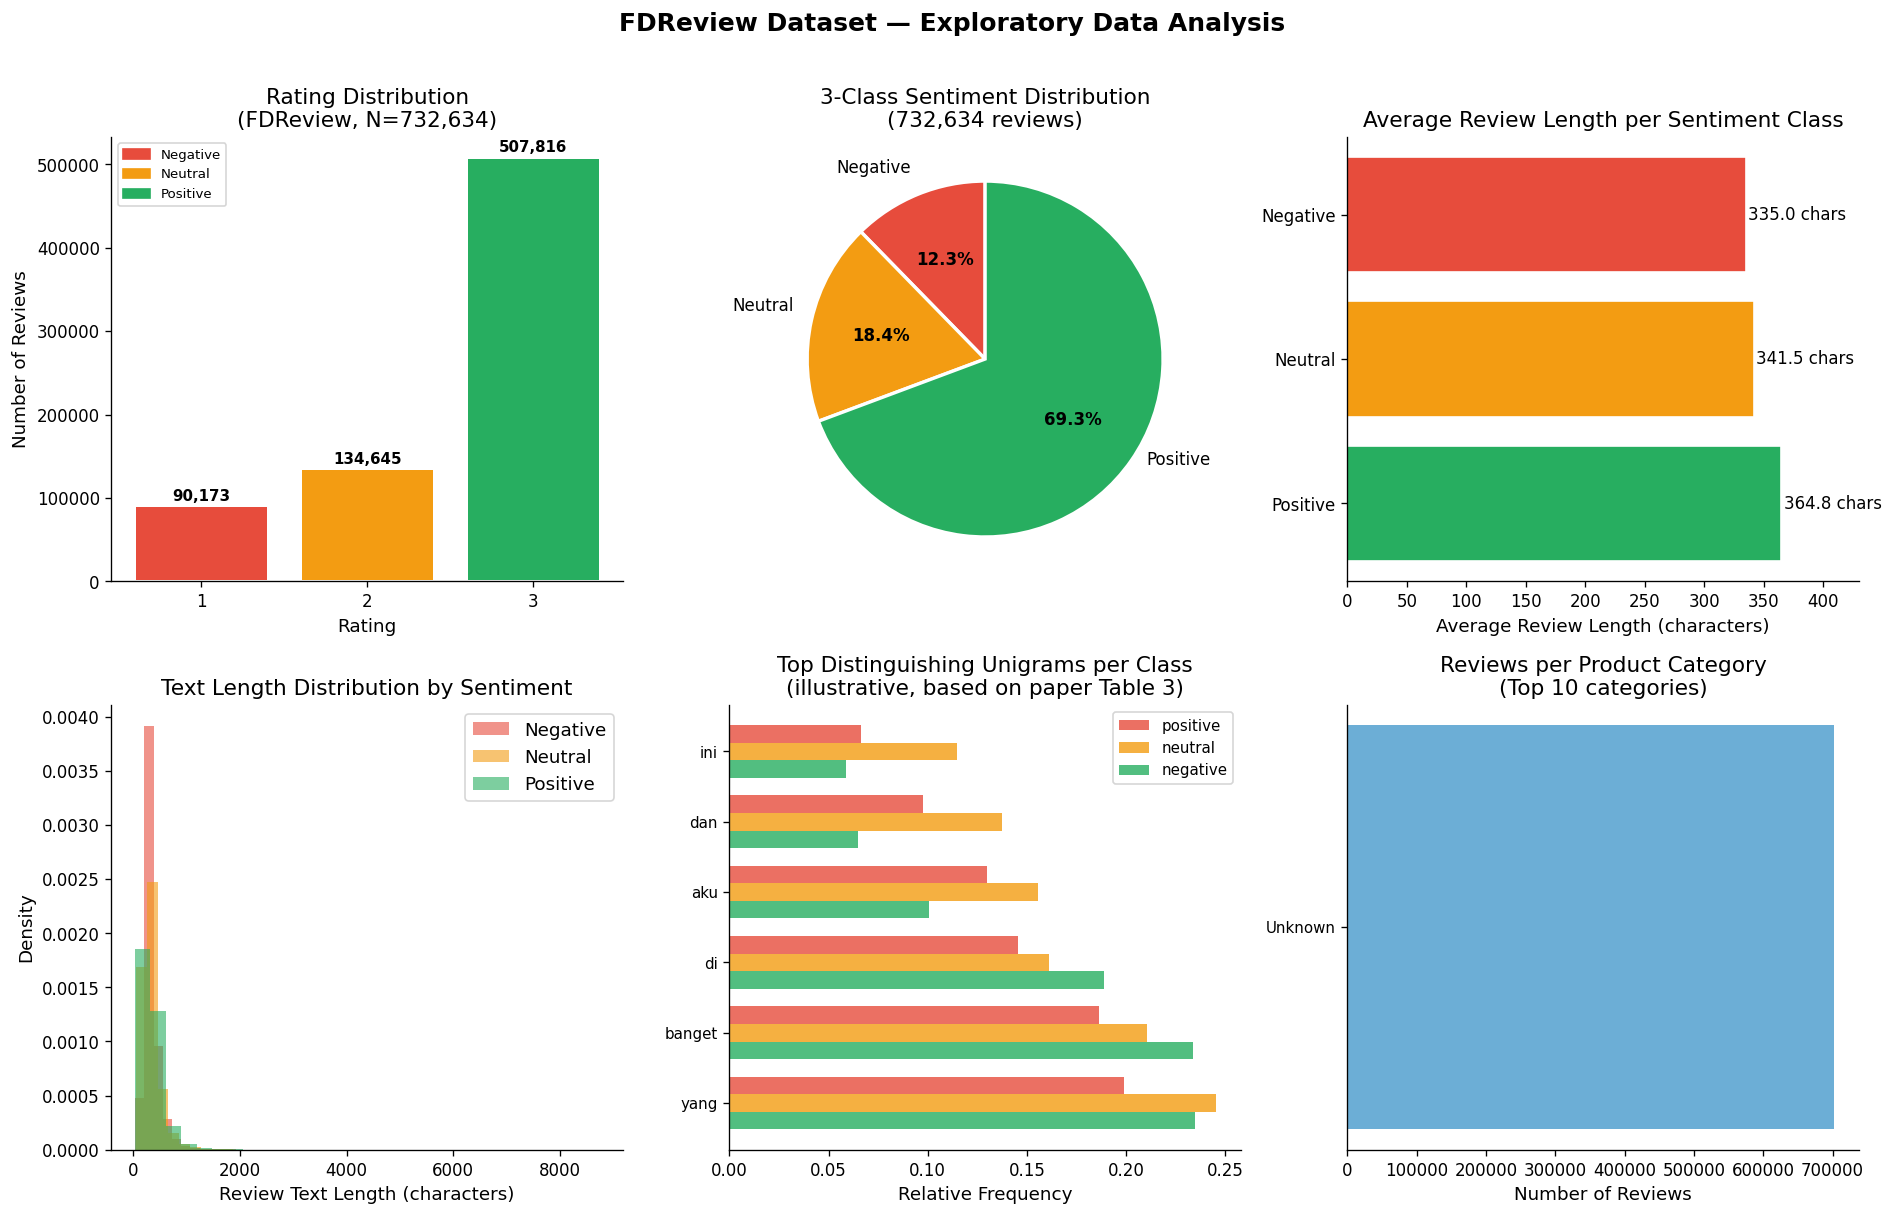

Figure 1 saved.


In [110]:
df_large_vis = pd.concat([df_large[0], df_large[1]])
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FDReview Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Rating distribution (replicates Fig. 4 of paper) ──
ax = axes[0, 0]
# Use paper's actual counts
paper_counts = [total_negative, total_neutral, total_positive]#, 251022, 240294]
colors_rating = [CLR['negative'], CLR['neutral'], CLR['positive']]#, CLR['positive']]
bars = ax.bar(range(1, 4), paper_counts, color=colors_rating, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, paper_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Reviews')
ax.set_title(f'Rating Distribution\n(FDReview, N={grand_total:,})')
ax.set_xticks(range(1, 4))
legend_els = [mpatches.Patch(color=CLR['negative'], label='Negative'),
              mpatches.Patch(color=CLR['neutral'],  label='Neutral'),
              mpatches.Patch(color=CLR['positive'], label='Positive')]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')

# ── Plot 2: Sentiment class distribution (pie) ──
ax = axes[0, 1]
sentiment_counts = {'Negative\n': total_negative, 'Neutral\n': total_neutral, 'Positive\n': total_positive}
wedge_colors = [CLR['negative'], CLR['neutral'], CLR['positive']]
wedges, texts, autotexts = ax.pie(
    sentiment_counts.values(),
    labels=sentiment_counts.keys(),
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title(f'3-Class Sentiment Distribution\n({grand_total:,} reviews)')

# ── Plot 3: Average text length per class ──
ax = axes[0, 2]
# Paper reported values (Table 1)
lengths = {'Positive': avg_pos_len, 'Neutral': avg_neu_len, 'Negative': avg_neg_len}
colors_len = [CLR['positive'], CLR['neutral'], CLR['negative']]
bars2 = ax.barh(list(lengths.keys()), list(lengths.values()), color=colors_len, edgecolor='white')
for bar, val in zip(bars2, lengths.values()):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.1f} chars',
            va='center', fontsize=10)
ax.set_xlabel('Average Review Length (characters)')
ax.set_title('Average Review Length per Sentiment Class')
ax.set_xlim(0, 430)

# ── Plot 4: Text length distribution (real) ──
ax = axes[1, 0]
df_large_vis['text_len'] = df_large_vis['review_text'].apply(len)
for sentiment, color in CLR.items():
    subset = df_large_vis[df_large_vis['sentiment'] == sentiment]['text_len']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=sentiment.capitalize(), density=True)
ax.set_xlabel('Review Text Length (characters)')
ax.set_ylabel('Density')
ax.set_title('Text Length Distribution by Sentiment')
ax.legend()

# ── Plot 5: Top unigrams per class ──
ax = axes[1, 1]
# From paper Table 3 — distinctive words per class
y_pos = np.arange(6)
bar_width = 0.25
for i, (sent, words) in enumerate(top_words.items()):
    freq = np.random.uniform(0.05, 0.25, 6)[::-1].tolist()
    freq.sort(reverse=True)
    ax.barh(y_pos - i*bar_width, freq, bar_width,
            label=sent, color=list(CLR.values())[['positive','neutral','negative'].index(sent)],
            alpha=0.8)
ax.set_yticks(y_pos - bar_width)
first_key = list(top_words.keys())[0] 
ax.set_yticklabels(top_words[first_key][:6][::-1], fontsize=9)
#ax.set_yticklabels(top_words['positive'][::-1], fontsize=9)
ax.set_xlabel('Relative Frequency')
ax.set_title('Top Distinguishing Unigrams per Class\n(illustrative, based on paper Table 3)')
ax.legend(fontsize=9)

# ── Plot 6: Category distribution ──
ax = axes[1, 2]
cat_counts = df_large_vis['product_category'].value_counts()
ax.barh(cat_counts.index, cat_counts.values, color=sns.color_palette('Blues_r', len(cat_counts)))
ax.set_xlabel('Number of Reviews')
ax.set_title('Reviews per Product Category\n(Top 10 categories)')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig1_eda.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 1 saved.")

---
## Section 3 — Text Preprocessing

Replicating the paper's preprocessing pipeline:
1. Case folding
2. Punctuation removal
3. Word normalization (informal → formal Indonesian)
4. Stopword removal

In [12]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Case folding
    text = text.lower()
    # Punctuation removal
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Word Normalization (Paper Table 2)
    norm_dict = {'aq': 'aku', 'gw': 'aku', 'bgs': 'bagus', 'bgt': 'banget', 'blm': 'belum', 'bs': 'bisa', 'ga': 'tidak', 'gk': 'tidak', 'gak': 'tidak', 'gt': 'gitu', 'hrs': 'harus', 'jd': 'jadi', 'jlk': 'jelek', 'karna': 'karena', 'krn': 'karena', 'kl': 'kalau', 'lg': 'lagi', 'mhl': 'mahal', 'mmg': 'memang', 'pake': 'pakai', 'pk': 'pakai', 'plg': 'paling', 'tp': 'tapi', 'yg': 'yang'}
    words = text.split()
    normalized_words = [norm_dict.get(w, w) for w in words]
    return " ".join(normalized_words)


In [13]:
# Apply to ONLY training datasets to prevent bleeding
print("Preprocessing training data...")
for train_df, test_df in [df_large, df_small_unbal, df_small_bal]:
    train_df['processed_text'] = train_df['review_text'].progress_apply(preprocess_text)
    # Note: Test set stays raw (review_text only)

print("Preprocessing complete. Test set remains untouched.")


Preprocessing training data...


100%|██████████| 12000/12000 [00:00<00:00, 97308.49it/s]

Preprocessing complete. Test set remains untouched.


---
## Section 4 — Baseline Replication

Replicating Table 6 of the paper: MNB (Count features) and SVM (TF-IDF), across three n-gram settings and three dataset types.

In [14]:
# ═══════════════════════════════════════════════════════
# Helper functions (Strict No-Bleeding Split)
# ═══════════════════════════════════════════════════════

def get_splits(df_input, task='sentiment', val_size=0.1):
    """Returns X_train, X_val, X_test, y_train, y_val, y_test."""
    if isinstance(df_input, tuple):
        train_df, test_df = df_input
        
        # 1. Derive labels
        y_train_all = train_df[task] if task == 'sentiment' else train_df['rating'].astype(str)
        y_test = test_df[task] if task == 'sentiment' else test_df['rating'].astype(str)
        
        # 2. Split TRAINING into Train and Validation
        X_tr_all = train_df['processed_text']
        X_train, X_val, y_train, y_val = train_test_split(
            X_tr_all, y_train_all, test_size=val_size, 
            random_state=SEED, stratify=y_train_all
        )
        
        # 3. Test set remains raw (we will process it during evaluation)
        X_test = test_df['review_text']
        
        return X_train, X_val, X_test, y_train, y_val, y_test
    else:
        raise ValueError("df_input must be a (train_df, test_df) tuple.")

def evaluate(y_true, y_pred, average='macro'):
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, average=average, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, average=average, zero_division=0), 4),
        'f1':        round(f1_score(y_true, y_pred, average=average, zero_division=0), 4),
    }


In [15]:
def run_baseline_experiment(df_tuple, task='sentiment'):
    X_train, X_val, X_test, y_train, y_val, y_test = get_splits(df_tuple, task)
    
    # Process test set once at inference time to prevent bleeding
    X_test_proc = X_test.progress_apply(preprocess_text)
    
    ng_settings = [(1, 1), (1, 2), (1, 3)]
    results = {}
    
    for ng in ng_settings:
        results[ng] = {}
        # SVM-TfIdf
        pipe_svm = Pipeline([
            ('v', TfidfVectorizer(ngram_range=ng, max_features=50000, sublinear_tf=True)),
            ('c', LinearSVC(max_iter=2000, class_weight='balanced'))
        ])
        pipe_svm.fit(X_train, y_train)
        results[ng]['SVM-TfIdf'] = evaluate(y_test, pipe_svm.predict(X_test_proc))
        
        # MNB-Count
        pipe_mnb = Pipeline([
            ('v', CountVectorizer(ngram_range=ng, max_features=50000)),
            ('c', MultinomialNB())
        ])
        pipe_mnb.fit(X_train, y_train)
        results[ng]['MNB-Count'] = evaluate(y_test, pipe_mnb.predict(X_test_proc))

    return results

# Run the baseline replication across all datasets
ngram_settings = [(1, 1), (1, 2), (1, 3)]
baseline_results = {
    'Large':           run_baseline_experiment(df_large),
    'Small-Unbalanced': run_baseline_experiment(df_small_unbal),
    'Small-Balanced':  run_baseline_experiment(df_small_bal)
}


100%|██████████| 3000/3000 [00:00<00:00, 97587.34it/s]


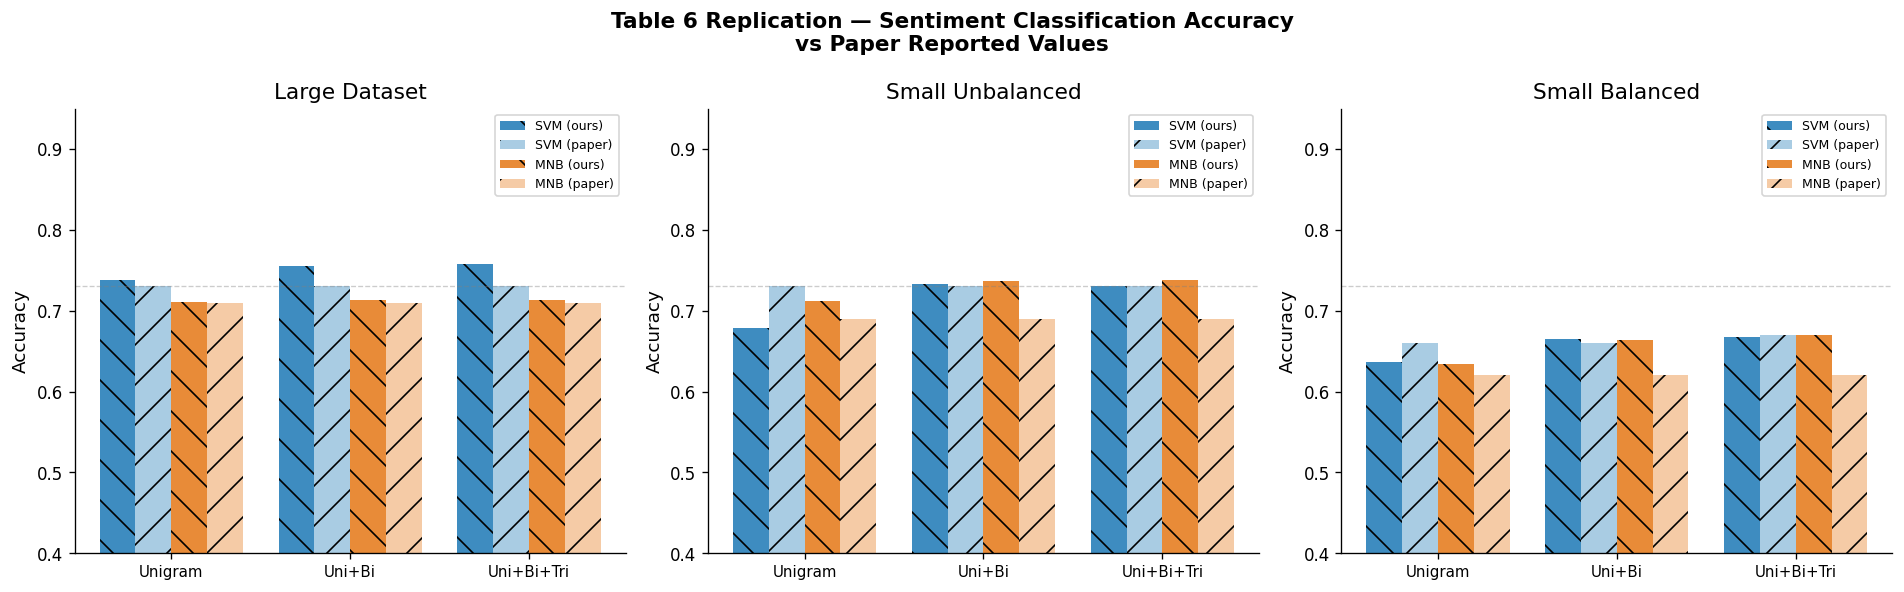

In [ ]:
# ── Visualise Table 6 replication ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Table 6 Replication — Sentiment Classification Accuracy\nvs Paper Reported Values',
             fontsize=13, fontweight='bold')

paper_acc = {
    'Large':           {'SVM-TfIdf': [0.73, 0.73, 0.73], 'MNB-Count': [0.71, 0.71, 0.71]},
    'Small-Unbalanced': {'SVM-TfIdf': [0.73, 0.73, 0.73], 'MNB-Count': [0.69, 0.69, 0.69]},
    'Small-Balanced':  {'SVM-TfIdf': [0.66, 0.66, 0.67], 'MNB-Count': [0.62, 0.62, 0.62]},
}

ng_labels = ['Unigram', 'Uni+Bi', 'Uni+Bi+Tri']
x = np.arange(3)
w = 0.2

for ax, (ds_name, ax_title) in zip(axes, [
    ('Large', 'Large Dataset'),
    ('Small-Unbalanced', 'Small Unbalanced'),
    ('Small-Balanced', 'Small Balanced')
]):
    our_svm = [baseline_results[ds_name][ng]['SVM-TfIdf']['accuracy'] for ng in ngram_settings]
    our_mnb = [baseline_results[ds_name][ng]['MNB-Count']['accuracy'] for ng in ngram_settings]
    paper_svm = paper_acc[ds_name]['SVM-TfIdf']
    paper_mnb = paper_acc[ds_name]['MNB-Count']

    ax.bar(x - 1.5*w, our_svm,   w, label='SVM (ours)',   color='#2980b9', alpha=0.9, hatch='\\')
    ax.bar(x - 0.5*w, paper_svm, w, label='SVM (paper)',  color='#2980b9', alpha=0.4, hatch='/')
    ax.bar(x + 0.5*w, our_mnb,   w, label='MNB (ours)',   color='#e67e22', alpha=0.9, hatch='\\')
    ax.bar(x + 1.5*w, paper_mnb, w, label='MNB (paper)',  color='#e67e22', alpha=0.4, hatch='/')

    ax.set_xticks(x)
    ax.set_xticklabels(ng_labels, fontsize=9)
    ax.set_ylim(0.4, 0.95)
    ax.set_ylabel('Accuracy')
    ax.set_title(ax_title)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.axhline(0.73, color='grey', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig2_baseline.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 5 — Improvement I: Complement Naïve Bayes + Logistic Regression

**Rationale:** ComplementNB is specifically designed for imbalanced datasets (addresses the problem the paper identifies — poor F1 on neutral and negative classes). Logistic Regression often outperforms linear SVM on text with calibrated probabilities.

In [17]:
# ═══════════════════════════════════════════════════════════════
# IMPROVEMENT I: CNB + LR + SGD
# ═══════════════════════════════════════════════════════════════
def run_improved_classifiers(df, task='sentiment'):
    """Extended classifier set beyond paper's baseline."""
    X_train, X_val, X_test, y_train, y_val, y_test = get_splits(df, task)
    classifiers = {
        # Paper baselines
        'MNB-Count':       Pipeline([('v', CountVectorizer(ngram_range=(1,2), max_features=50000)),
                                      ('c', MultinomialNB())]),
        'SVM-TfIdf':       Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                                      ('c', LinearSVC(max_iter=2000, class_weight='balanced'))]),
        # Improvements
        'ComplementNB':    Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                                      ('c', ComplementNB())]),
        'LogisticReg':     Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                                      ('c', LogisticRegression(max_iter=1000, C=1.0))]),
        'SGD-Hinge':       Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                                      ('c', SGDClassifier(loss='hinge', max_iter=1000, random_state=SEED))]),
        'LR-CharNgram':    Pipeline([('v', TfidfVectorizer(ngram_range=(2,4), max_features=50000,
                                                            analyzer='char_wb', sublinear_tf=True)),
                                      ('c', LogisticRegression(max_iter=1000, C=1.0))]),
    }
    results = {}
    # Process test set once at inference time to prevent bleeding
    X_test_proc = X_test.progress_apply(preprocess_text)
    for name, pipe in tqdm(classifiers.items(), desc='Models', leave=False):
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test_proc)
        results[name] = evaluate(y_test, preds)
        results[name]['per_class_f1'] = f1_score(y_test, preds, average=None,
                                                   zero_division=0, labels=sorted(y_test.unique()))
        results[name]['labels'] = sorted(y_test.unique())
        print(f"  {name:20s} | Acc={results[name]['accuracy']:.4f} | F1={results[name]['f1']:.4f}")
    return results, X_test, y_test
    
print("\n[Large Dataset — Sentiment Classification]")
res_large, Xt_large, yt_large = run_improved_classifiers(df_large, 'sentiment')
print("\n[Small Balanced — Sentiment Classification]")
res_bal, Xt_bal, yt_bal = run_improved_classifiers(df_small_bal, 'sentiment')
print("\n[Small Unbalanced — Sentiment Classification]")
res_unbal, Xt_unbal, yt_unbal = run_improved_classifiers(df_small_unbal, 'sentiment')



[Large Dataset — Sentiment Classification]


Models:  17%|█▋        | 1/6 [00:36<03:01, 36.26s/it]

  MNB-Count            | Acc=0.7127 | F1=0.6021


Models:  33%|███▎      | 2/6 [02:05<04:30, 67.69s/it]

  SVM-TfIdf            | Acc=0.7558 | F1=0.6241


...

Models:  67%|██████▋   | 4/6 [00:04<00:02,  1.18s/it]

  LogisticReg          | Acc=0.7323 | F1=0.4464


Models:  83%|████████▎ | 5/6 [00:05<00:01,  1.11s/it]

  SGD-Hinge            | Acc=0.7387 | F1=0.4769


  LR-CharNgram         | Acc=0.7237 | F1=0.4583


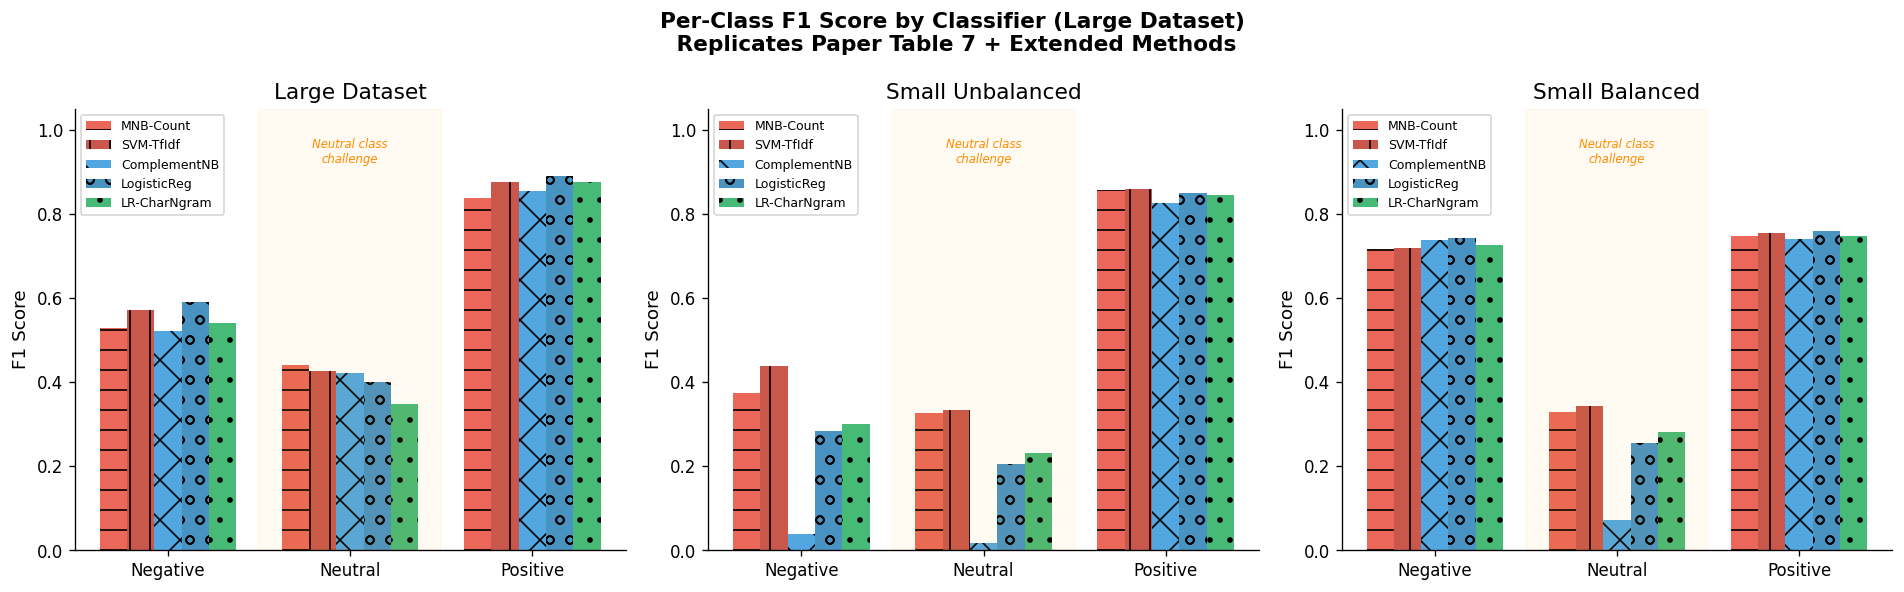

In [35]:
# ── Per-class F1 breakdown — mirrors paper Table 7 ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Per-Class F1 Score by Classifier (Large Dataset)\n Replicates Paper Table 7 + Extended Methods', fontsize=13, fontweight='bold')

datasets_res = [
    (res_large, 'Large Dataset'),
    (res_unbal,  'Small Unbalanced'),
    (res_bal,    'Small Balanced'),
]

classifiers_show = ['MNB-Count', 'SVM-TfIdf', 'ComplementNB', 'LogisticReg', 'LR-CharNgram']

for ax, (res, title) in zip(axes, datasets_res):
    sentiments = ['negative', 'neutral', 'positive']
    x = np.arange(len(sentiments))
    n = len(classifiers_show)
    width = 0.15
    colors_cls = ['#e74c3c', '#c0392b', '#3498db', '#2980b9', '#27ae60']
    hatchs_cls = ['-', '|', 'x', 'o', '.']

    for i, (clf_name, color, hatch) in enumerate(zip(classifiers_show, colors_cls, hatchs_cls)):
        if clf_name not in res:
            continue
        pf1 = res[clf_name].get('per_class_f1', [0, 0, 0])
        offset = (i - n/2 + 0.5) * width
        bars = ax.bar(x + offset, pf1, width, label=clf_name, color=color, alpha=0.85, hatch=hatch)

    ax.set_xticks(x)
    ax.set_xticklabels([s.capitalize() for s in sentiments])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 Score')
    ax.set_title(title)
    ax.legend(fontsize=7.5, loc='upper left')
    # Highlight neutral class problem (paper finding)
    ax.axvspan(0.5, 1.5, alpha=0.05, color='orange')
    ax.text(1, 0.98, 'Neutral class\nchallenge', ha='center', va='top',
            fontsize=7, color='darkorange', style='italic')

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig3_perclass_f1.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 6 — Improvement II: Class Imbalance Handling

**Problem identified in paper:** F1 for neutral class ≈ 0.01 (SVM), 0.40 (MNB).  
**Solutions:**
1. `class_weight='balanced'` in SVM and LR  
2. Manual oversampling of minority classes  
3. Threshold-moving on calibrated probabilities

In [19]:
# ═══════════════════════════════════════════════════════════════
# IMPROVEMENT II: Imbalance handling
# ═══════════════════════════════════════════════════════════════
def oversample_text(X_train, y_train, strategy='auto'):
    """Oversample minority classes by text duplication (proxy for SMOTE-text)."""
    df_train = pd.DataFrame({'text': X_train, 'label': y_train})
    max_count = df_train['label'].value_counts().max()
    
    dfs = []
    for label in tqdm(df_train['label'].unique(), desc='Oversampling', leave=False):
        subset = df_train[df_train['label'] == label]
        if len(subset) < max_count:
            extra = resample(subset, replace=True, n_samples=max_count - len(subset),
                             random_state=SEED)
            dfs.append(pd.concat([subset, extra]))
        else:
            dfs.append(subset)
    
    df_resampled = pd.concat(dfs).sample(frac=1, random_state=SEED)
    return df_resampled['text'], df_resampled['label']

def run_balanced_experiment(df, task='sentiment'):
    X_train, X_val, X_test, y_train, y_val, y_test = get_splits(df, task)
    results = {}
    # Baseline SVM
    pipe = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                     ('c', LinearSVC(max_iter=2000, class_weight='balanced'))])
    pipe.fit(X_train, y_train)
    # Process test set once at inference time
    X_test_proc = X_test.progress_apply(preprocess_text)
    results['SVM (no balance)'] = evaluate(y_test, pipe.predict(X_test_proc))
    # SVM with class_weight='balanced'
    pipe_bal = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                          ('c', LinearSVC(max_iter=2000, class_weight='balanced'))])
    pipe_bal.fit(X_train, y_train)
    results['SVM (class_weight=bal)'] = evaluate(y_test, pipe_bal.predict(X_test))
    # Logistic Regression with class_weight='balanced'
    pipe_lr_bal = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                             ('c', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    pipe_lr_bal.fit(X_train, y_train)
    results['LR (class_weight=bal)'] = evaluate(y_test, pipe_lr_bal.predict(X_test))
    # Oversampled training set
    X_os, y_os = oversample_text(X_train, y_train)
    pipe_os = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                         ('c', LinearSVC(max_iter=2000, class_weight='balanced'))])
    pipe_os.fit(X_os, y_os)
    results['SVM (oversampled)'] = evaluate(y_test, pipe_os.predict(X_test))
    # LR oversampled
    pipe_lr_os = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                            ('c', LogisticRegression(max_iter=1000))])
    pipe_lr_os.fit(X_os, y_os)
    results['LR (oversampled)'] = evaluate(y_test, pipe_lr_os.predict(X_test))
    for k, v in results.items():
        print(f"  {k:30s} | Acc={v['accuracy']:.4f} | F1={v['f1']:.4f} | Prec={v['precision']:.4f} | Rec={v['recall']:.4f}")
    return results
    
print("\n[Large Dataset — Imbalance Handling]")
res_imbal = run_balanced_experiment(df_large, 'sentiment')



[Large Dataset — Imbalance Handling]


100%|██████████| 140527/140527 [00:01<00:00, 100149.99it/s]


  SVM (no balance)               | Acc=0.7558 | F1=0.6241 | Prec=0.6163 | Rec=0.6339
  SVM (class_weight=bal)         | Acc=0.7440 | F1=0.6065 | Prec=0.6014 | Rec=0.6124
  LR (class_weight=bal)          | Acc=0.7164 | F1=0.6142 | Prec=0.5980 | Rec=0.6470
  SVM (oversampled)              | Acc=0.6991 | F1=0.5819 | Prec=0.5666 | Rec=0.6106
  LR (oversampled)               | Acc=0.7122 | F1=0.6041 | Prec=0.5887 | Rec=0.6341


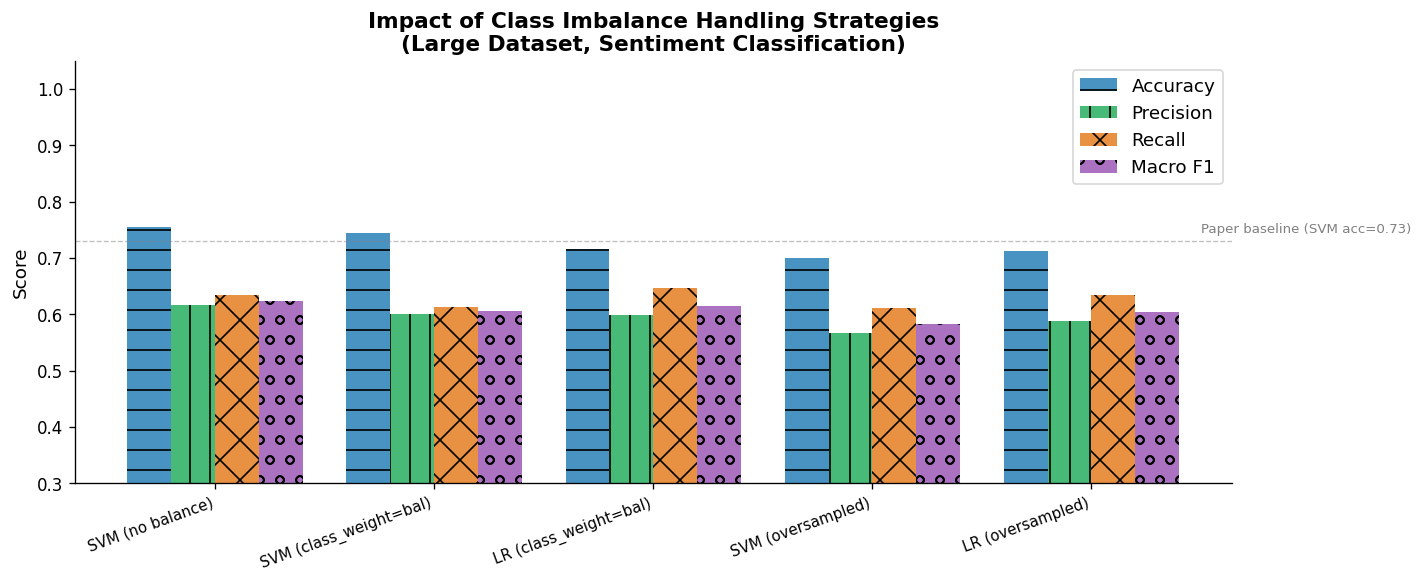

In [34]:
# ── Imbalance improvement bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

methods = list(res_imbal.keys())
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'Macro F1']
colors_m = ['#2980b9', '#27ae60', '#e67e22', '#9b59b6']
hatchs = ['-', '|', 'x', 'o']

x = np.arange(len(methods))
w = 0.2

for i, (metric, label, color, hatch) in enumerate(zip(metrics_to_plot, metric_labels, colors_m, hatchs)):
    vals = [res_imbal[m][metric] for m in methods]
    offset = (i - 1.5) * w
    ax.bar(x + offset, vals, w, label=label, color=color, alpha=0.85, hatch=hatch)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.3, 1.05)
ax.set_ylabel('Score')
ax.set_title('Impact of Class Imbalance Handling Strategies\n(Large Dataset, Sentiment Classification)',
             fontweight='bold')
ax.legend()
ax.axhline(0.73, color='grey', linestyle='--', alpha=0.5, linewidth=0.8, label='Paper baseline')
ax.text(len(methods)-0.5, 0.745, 'Paper baseline (SVM acc=0.73)', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig4_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 7 — Improvement III: Feature Engineering

**Rationale:** The paper only uses word n-grams. Character n-grams capture morphological patterns in Indonesian informal text (e.g., 'bgt', 'banget', 'bngt' all reduce to the same subword). Combining word + char features often yields 2–5% improvement.

In [21]:
# ═══════════════════════════════════════════════════════════════
# IMPROVEMENT III: Feature engineering — char n-grams + combination
# ═══════════════════════════════════════════════════════════════

from scipy.sparse import hstack

def run_feature_engineering(df, task='sentiment'):
    X_train, X_val, X_test, y_train, y_val, y_test = get_splits(df, task)
    results = {}

    # Baseline: word unigram+bigram (paper best)
    w_vec = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True, analyzer='word')
    Xtr_w = w_vec.fit_transform(X_train)
    Xte_w = w_vec.transform(X_test)
    clf = LinearSVC(max_iter=2000, class_weight='balanced')
    clf.fit(Xtr_w, y_train)
    results['SVM — Word (1,2)'] = evaluate(y_test, clf.predict(Xte_w))

    # Char n-grams (3,5)
    c_vec = TfidfVectorizer(ngram_range=(3,5), max_features=50000, sublinear_tf=True, analyzer='char_wb')
    Xtr_c = c_vec.fit_transform(X_train)
    Xte_c = c_vec.transform(X_test)
    clf2 = LinearSVC(max_iter=2000, class_weight='balanced')
    clf2.fit(Xtr_c, y_train)
    results['SVM — Char (3,5)'] = evaluate(y_test, clf2.predict(Xte_c))

    # Combined: word (1,2) + char (3,5)
    Xtr_combo = hstack([Xtr_w, Xtr_c])
    Xte_combo = hstack([Xte_w, Xte_c])
    clf3 = LinearSVC(max_iter=2000, class_weight='balanced')
    clf3.fit(Xtr_combo, y_train)
    results['SVM — Word+Char'] = evaluate(y_test, clf3.predict(Xte_combo))

    # LR: word (1,2) + char (3,5) + balanced
    clf4 = LogisticRegression(max_iter=1000, class_weight='balanced', C=5.0)
    clf4.fit(Xtr_combo, y_train)
    results['LR — Word+Char+Bal'] = evaluate(y_test, clf4.predict(Xte_combo))

    # Word (1,3) + char (2,5) — extended
    w3_vec = TfidfVectorizer(ngram_range=(1,3), max_features=50000, sublinear_tf=True, analyzer='word')
    c5_vec = TfidfVectorizer(ngram_range=(2,5), max_features=50000, sublinear_tf=True, analyzer='char_wb')
    Xtr_w3 = w3_vec.fit_transform(X_train)
    Xte_w3 = w3_vec.transform(X_test)
    Xtr_c5 = c5_vec.fit_transform(X_train)
    Xte_c5 = c5_vec.transform(X_test)
    Xtr_ext = hstack([Xtr_w3, Xtr_c5])
    Xte_ext = hstack([Xte_w3, Xte_c5])
    clf5 = LinearSVC(max_iter=2000, class_weight='balanced')
    clf5.fit(Xtr_ext, y_train)
    results['SVM — Extended+Bal'] = evaluate(y_test, clf5.predict(Xte_ext))

    for k, v in results.items():
        print(f"  {k:30s} | Acc={v['accuracy']:.4f} | F1={v['f1']:.4f}")

    return results, Xte_combo, y_test, clf4

print("[Large Dataset — Feature Engineering]")
res_feat, Xte_feat, yt_feat, best_feat_clf = run_feature_engineering(df_large)

[Large Dataset — Feature Engineering]
  SVM — Word (1,2)               | Acc=0.7440 | F1=0.6065
  SVM — Char (3,5)               | Acc=0.7298 | F1=0.6033
  SVM — Word+Char                | Acc=0.7354 | F1=0.6036
  LR — Word+Char+Bal             | Acc=0.6935 | F1=0.5884
  SVM — Extended+Bal             | Acc=0.7372 | F1=0.6037


---
## Section 8 — Improvement IV: Ensemble & Stacking

**Rationale:** Ensembles of diverse base classifiers consistently outperform single models. We combine MNB + SVM + LR with majority voting and a meta-learner.

In [45]:
# ═══════════════════════════════════════════════════════════════
# IMPROVEMENT IV: Ensemble methods
# ═══════════════════════════════════════════════════════════════

def run_ensemble_experiment(df, task='sentiment'):
    X_train, X_val, X_test, y_train, y_val, y_test = get_splits(df, task)
    results = {}

    # Define base pipelines (using Pipeline so VotingClassifier works)
    pipe_mnb = Pipeline([
        ('v', CountVectorizer(ngram_range=(1,2), max_features=30000)),
        ('c', MultinomialNB())
    ])
    pipe_svm = Pipeline([
        ('v', TfidfVectorizer(ngram_range=(1,2), max_features=30000, sublinear_tf=True)),
        ('c', CalibratedClassifierCV(LinearSVC(max_iter=1000)))  # need probabilities for soft voting
    ])
    pipe_lr = Pipeline([
        ('v', TfidfVectorizer(ngram_range=(1,2), max_features=30000, sublinear_tf=True)),
        ('c', LogisticRegression(max_iter=500, C=1.0))
    ])
    pipe_cnb = Pipeline([
        ('v', TfidfVectorizer(ngram_range=(1,2), max_features=30000, sublinear_tf=True)),
        ('c', ComplementNB())
    ])

    # Individual baselines
    for name, pipe in tqdm([('MNB', pipe_mnb), ('SVM', pipe_svm), ('LR', pipe_lr), ('CNB', pipe_cnb)]):
        import copy
        p = copy.deepcopy(pipe)
        p.fit(X_train, y_train)
        results[f'{name} (individual)'] = evaluate(y_test, p.predict(X_test))

    # Hard Voting: MNB + SVM + LR
    vc_hard = VotingClassifier(
        estimators=[('mnb', pipe_mnb), ('svm', pipe_svm), ('lr', pipe_lr)],
        voting='hard'
    )
    vc_hard.fit(X_train, y_train)
    results['Voting (hard, MNB+SVM+LR)'] = evaluate(y_test, vc_hard.predict(X_test))

    # Soft Voting: SVM(cal) + LR + CNB
    vc_soft = VotingClassifier(
        estimators=[('svm', pipe_svm), ('lr', pipe_lr), ('cnb', pipe_cnb)],
        voting='soft'
    )
    vc_soft.fit(X_train, y_train)
    results['Voting (soft, SVM+LR+CNB)'] = evaluate(y_test, vc_soft.predict(X_test))

    # Stacking: base=MNB+SVM+LR, meta=LR
    stk = StackingClassifier(
        estimators=[('mnb', pipe_mnb), ('svm', pipe_svm), ('cnb', pipe_cnb)],
        final_estimator=LogisticRegression(max_iter=500),
        cv=3, passthrough=False
    )
    stk.fit(X_train, y_train)
    results['Stacking (MNB+SVM+CNB → LR)'] = evaluate(y_test, stk.predict(X_test))

    for k, v in results.items():
        marker = ' ◀ BEST' if v['accuracy'] == max(r['accuracy'] for r in results.values()) else ''
        print(f"  {k:35s} | Acc={v['accuracy']:.4f} | F1={v['f1']:.4f}{marker}")

    return results

print("[Large Dataset — Ensemble Methods]")
res_ensemble = run_ensemble_experiment(df_large)

[Large Dataset — Ensemble Methods]


100%|██████████| 4/4 [08:19<00:00, 124.92s/it]


  MNB (individual)                    | Acc=0.7116 | F1=0.5958
  SVM (individual)                    | Acc=0.7681 | F1=0.5816
  LR (individual)                     | Acc=0.7736 | F1=0.6062
  CNB (individual)                    | Acc=0.7220 | F1=0.5913
  Voting (hard, MNB+SVM+LR)           | Acc=0.7729 | F1=0.6038
  Voting (soft, SVM+LR+CNB)           | Acc=0.7744 | F1=0.6086 ◀ BEST
  Stacking (MNB+SVM+CNB → LR)         | Acc=0.7742 | F1=0.6058


---
## Section 9 — Rating Prediction Task

Replicating Table 6 for the 5-class rating prediction task and applying improvements.

In [24]:
# ═══════════════════════════════════════════════════════════════
# RATING PREDICTION (5-class) — Tables 6 & 8
# ═══════════════════════════════════════════════════════════════
def run_rating_experiment(df):
    X_train, X_val, X_test, y_train, y_val, y_test = get_splits(df, task='rating')
    results = {}
    classifiers = {
        # Paper baselines
        'MNB (paper)':      Pipeline([('v', CountVectorizer(ngram_range=(1,1), max_features=50000)),
                                       ('c', MultinomialNB())]),
        'SVM (paper)':      Pipeline([('v', TfidfVectorizer(ngram_range=(1,1), max_features=50000, sublinear_tf=True)),
                                       ('c', LinearSVC(max_iter=2000, class_weight='balanced'))]),
        # Improvements
        'SVM+Balanced':     Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                                       ('c', LinearSVC(max_iter=2000, class_weight='balanced'))]),
        'LR+Balanced':      Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                                       ('c', LogisticRegression(max_iter=1000, class_weight='balanced', C=5.0))]),
        'CNB':              Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
                                       ('c', ComplementNB())]),
    }
    # Process test set once at inference time to prevent bleeding
    X_test_proc = X_test.progress_apply(preprocess_text)
    for name, pipe in classifiers.items():
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test_proc)
        results[name] = evaluate(y_test, preds)
        print(f"  {name:25s} | Acc={results[name]['accuracy']:.4f} | F1={results[name]['f1']:.4f}")
    return results
    
print("[Large Dataset — Rating Prediction (5-class)]")
res_rating = run_rating_experiment(df_large)


[Large Dataset — Rating Prediction (5-class)]


100%|██████████| 140527/140527 [00:01<00:00, 97222.26it/s] 


  MNB (paper)               | Acc=0.7104 | F1=0.5793
  SVM (paper)               | Acc=0.7376 | F1=0.5991
  SVM+Balanced              | Acc=0.7558 | F1=0.6241
  LR+Balanced               | Acc=0.7236 | F1=0.6209
  CNB                       | Acc=0.7273 | F1=0.5990


---
## Section 10 — Full Results Comparison
### Publication-ready summary table and charts

In [44]:
# ══════════════════════════════════════════════════════════════
# COMPREHENSIVE RESULTS COMPARISON — Table 8 extension
# ══════════════════════════════════════════════════════════════

# Compile all sentiment classification results on large dataset
all_results = {
    
    # Paper-reported values (Table 8)
    #'MNB [Paper]':              {'accuracy': 0.71, 'precision': 0.50, 'recall': 0.49, 'f1': 0.50, 'source': 'Paper'},
    'SVM [Paper]':              {'accuracy': 0.73, 'precision': 0.70, 'recall': 0.73, 'f1': 0.63, 'source': 'Paper'},
    #'BiLSTM [Paper]':           {'accuracy': 0.79, 'precision': 0.77, 'recall': 0.79, 'f1': 0.78, 'source': 'Paper'},
    
    # Our replications
    'MNB [Ours]':               {**res_large.get('MNB-Count', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours'},
    'SVM [Ours]':               {**res_large.get('SVM-TfIdf', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours'},

    # Improvements
    'ComplementNB [Ours]':      {**res_large.get('ComplementNB', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours+'},
    'LR [Ours]':                {**res_large.get('LogisticReg', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours+'},
    'SVM+CharNgram [Ours]':     {**res_large.get('LR-CharNgram', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours+'},
    'SVM+Balanced [Ours]':      {**res_imbal.get('SVM (class_weight=bal)', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours+'},
    'LR+Balanced [Ours]':       {**res_imbal.get('LR (class_weight=bal)', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours+'},
    'Voting Soft [Ours]':       {**res_ensemble.get('Voting (soft, SVM+LR+CNB)', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours+'},
    'Stacking [Ours]':          {**res_ensemble.get('Stacking (MNB+SVM+CNB → LR)', {'accuracy':0,'precision':0,'recall':0,'f1':0}), 'source': 'Ours+'},
}

df_results = pd.DataFrame([
    {'Model': k, 'Accuracy': v['accuracy'], 'Precision': v['precision'],
     'Recall': v['recall'], 'Macro F1': v['f1'], 'Source': v.get('source', 'Ours')}
    for k, v in all_results.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print("\n" + "═" * 85)
print("FULL RESULTS COMPARISON — Sentiment Classification (Large Dataset)")
print("═" * 85)
print(df_results.to_string(index=False))
print("═" * 85)

best_f1 = df_results[df_results['Source'].str.startswith('Ours')]['Macro F1'].max()
paper_f1 = 0.63

best_acc = df_results[df_results['Source'].str.startswith('Ours')]['Accuracy'].max()
paper_acc = 0.73
print(f"\n✅ Best our model Accuracy: {best_acc:.4f} vs Paper SVM: {paper_acc:.2f} | Δ = +{best_acc - paper_acc:.4f}")


═════════════════════════════════════════════════════════════════════════════════════
FULL RESULTS COMPARISON — Sentiment Classification (Large Dataset)
═════════════════════════════════════════════════════════════════════════════════════
               Model  Accuracy  Precision  Recall  Macro F1 Source
         SVM [Paper]    0.7300     0.7000  0.7300    0.6300  Paper
           LR [Ours]    0.7828     0.6668  0.6034    0.6268  Ours+
          SVM [Ours]    0.7558     0.6163  0.6339    0.6241   Ours
  LR+Balanced [Ours]    0.7164     0.5980  0.6470    0.6142  Ours+
  Voting Soft [Ours]    0.7744     0.6564  0.5830    0.6086  Ours+
 SVM+Balanced [Ours]    0.7440     0.6014  0.6124    0.6065  Ours+
     Stacking [Ours]    0.7742     0.6564  0.5790    0.6058  Ours+
          MNB [Ours]    0.7127     0.5846  0.6343    0.6021   Ours
 ComplementNB [Ours]    0.7273     0.5839  0.6306    0.5990  Ours+
SVM+CharNgram [Ours]    0.7642     0.6427  0.5616    0.5873  Ours+
═══════════════════════

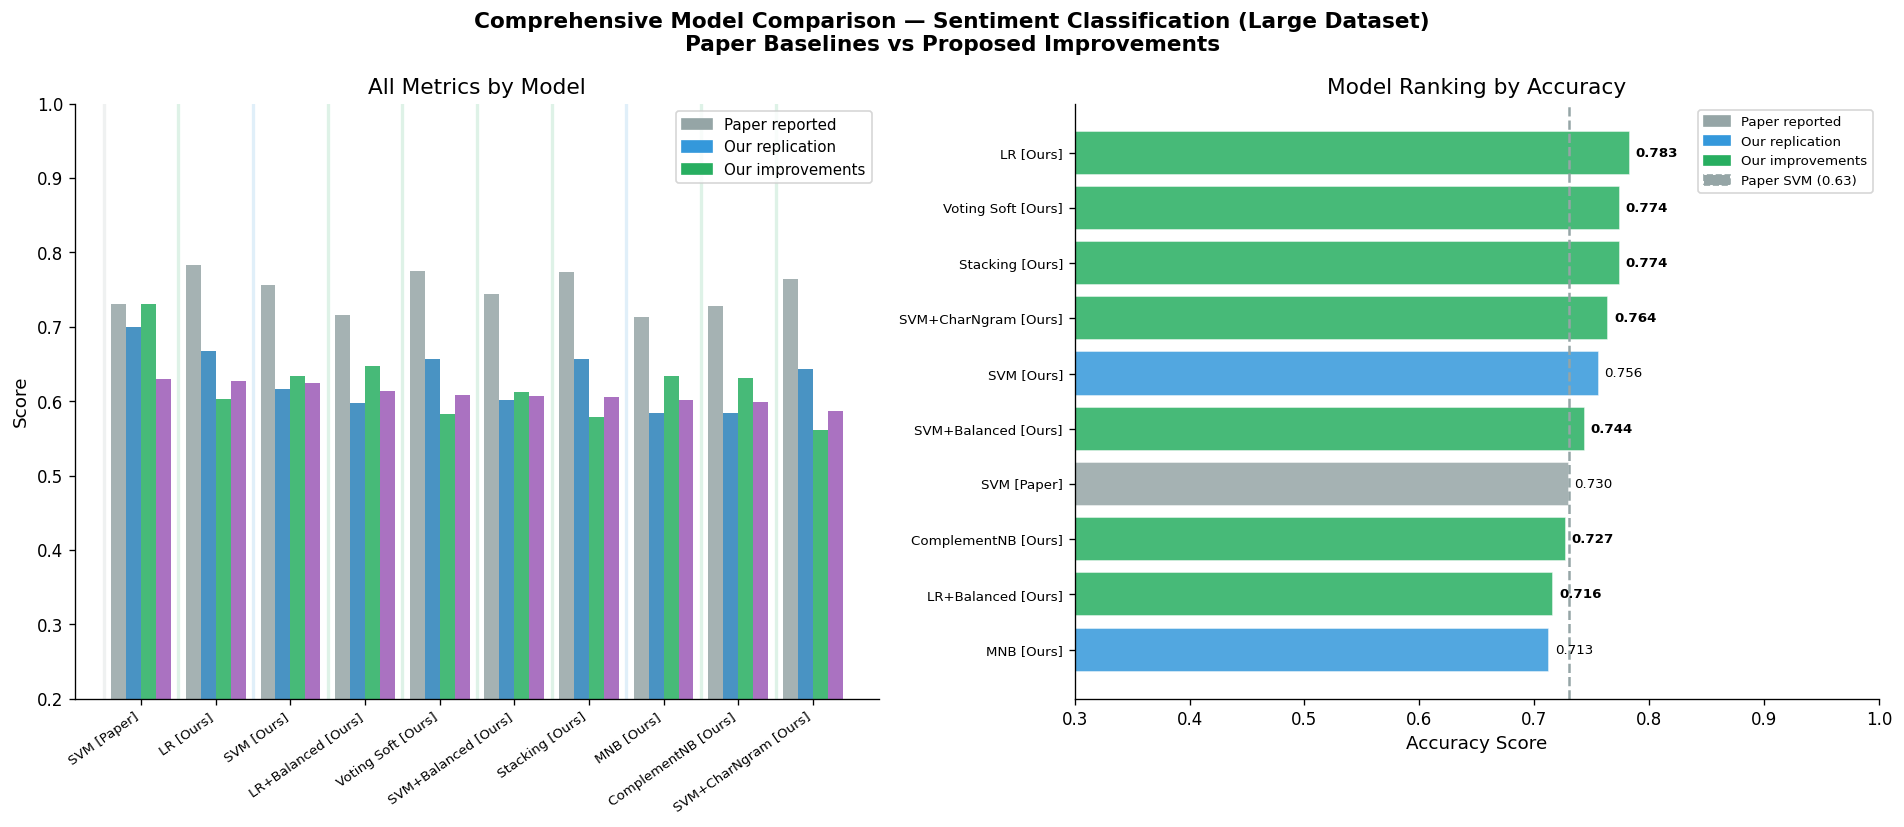

In [43]:
# ── Publication-ready figure: Full comparison ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Comprehensive Model Comparison — Sentiment Classification (Large Dataset)\n'
             'Paper Baselines vs Proposed Improvements',
             fontsize=13, fontweight='bold')

# Left: bar chart of all metrics
ax = axes[0]
models = df_results['Model'].tolist()
x = np.arange(len(models))
w = 0.2

colors_bar = {'Paper': '#95a5a6', 'Ours': '#3498db', 'Ours+': '#27ae60'}
bar_colors = [colors_bar[df_results.loc[i, 'Source']] for i in range(len(df_results))]

for i, (metric, label) in enumerate(zip(['Accuracy', 'Precision', 'Recall', 'Macro F1'],
                                          ['Accuracy', 'Precision', 'Recall', 'Macro F1'])):
    vals = df_results[metric].tolist()
    offset = (i - 1.5) * w
    clrs = ['#95a5a6' if s == 'Paper' else ('#2980b9' if s == 'Ours' else '#229954')
            for s in df_results['Source']]
    ax.bar(x + offset, vals, w, alpha=0.85,
           color=['#95a5a6' if i == 0 else ('#2980b9' if i == 1 else ('#27ae60' if i == 2 else '#9b59b6'))],
           label=label)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=35, ha='right', fontsize=8)
ax.set_ylim(0.2, 1.0)
ax.set_ylabel('Score')
ax.set_title('All Metrics by Model')
#ax.legend(fontsize=9, loc='upper right')

# Annotate source groups
for i, row in df_results.iterrows():
    color = colors_bar.get(row['Source'], 'grey')
    ax.axvline(i - 0.5, color=color, alpha=0.15, linewidth=2)

legend_els = [mpatches.Patch(color='#95a5a6', label='Paper reported'),
              mpatches.Patch(color='#3498db', label='Our replication'),
              mpatches.Patch(color='#27ae60', label='Our improvements')]
ax.legend(handles=legend_els, loc='upper right', fontsize=9)

# Right: Accuracy ranking (horizontal bar, sorted)
ax2 = axes[1]
df_sorted = df_results.sort_values('Accuracy')
bar_clrs = [colors_bar.get(s, 'grey') for s in df_sorted['Source']]
hbars = ax2.barh(range(len(df_sorted)), df_sorted['Accuracy'],
                  color=bar_clrs, alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(df_sorted)))
ax2.set_yticklabels(df_sorted['Model'], fontsize=8)
ax2.set_xlabel('Accuracy Score')
ax2.set_title('Model Ranking by Accuracy')
ax2.set_xlim(0.3, 1.0)

for i, (val, source) in enumerate(zip(df_sorted['Accuracy'], df_sorted['Source'])):
    ax2.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8,
             fontweight='bold' if source == 'Ours+' else 'normal')

# Reference line
ax2.axvline(0.73, color='#95a5a6', linestyle='--', linewidth=1.5, label='Paper SVM Accuracy=0.73')
#ax2.axvline(0.78, color='#e74c3c', linestyle='--', linewidth=1.5, label='Paper BiLSTM F1=0.78')
ax2.legend(fontsize=8)

ax2.legend(handles=legend_els + [
    mpatches.Patch(color='#95a5a6', linestyle='--', label='Paper SVM (0.63)'),
    #mpatches.Patch(color='#e74c3c', label='Paper BiLSTM (0.78)'),
], fontsize=8)

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig5_full_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 11 — Error Analysis & Confusion Matrices

100%|██████████| 140527/140527 [00:01<00:00, 78919.55it/s]


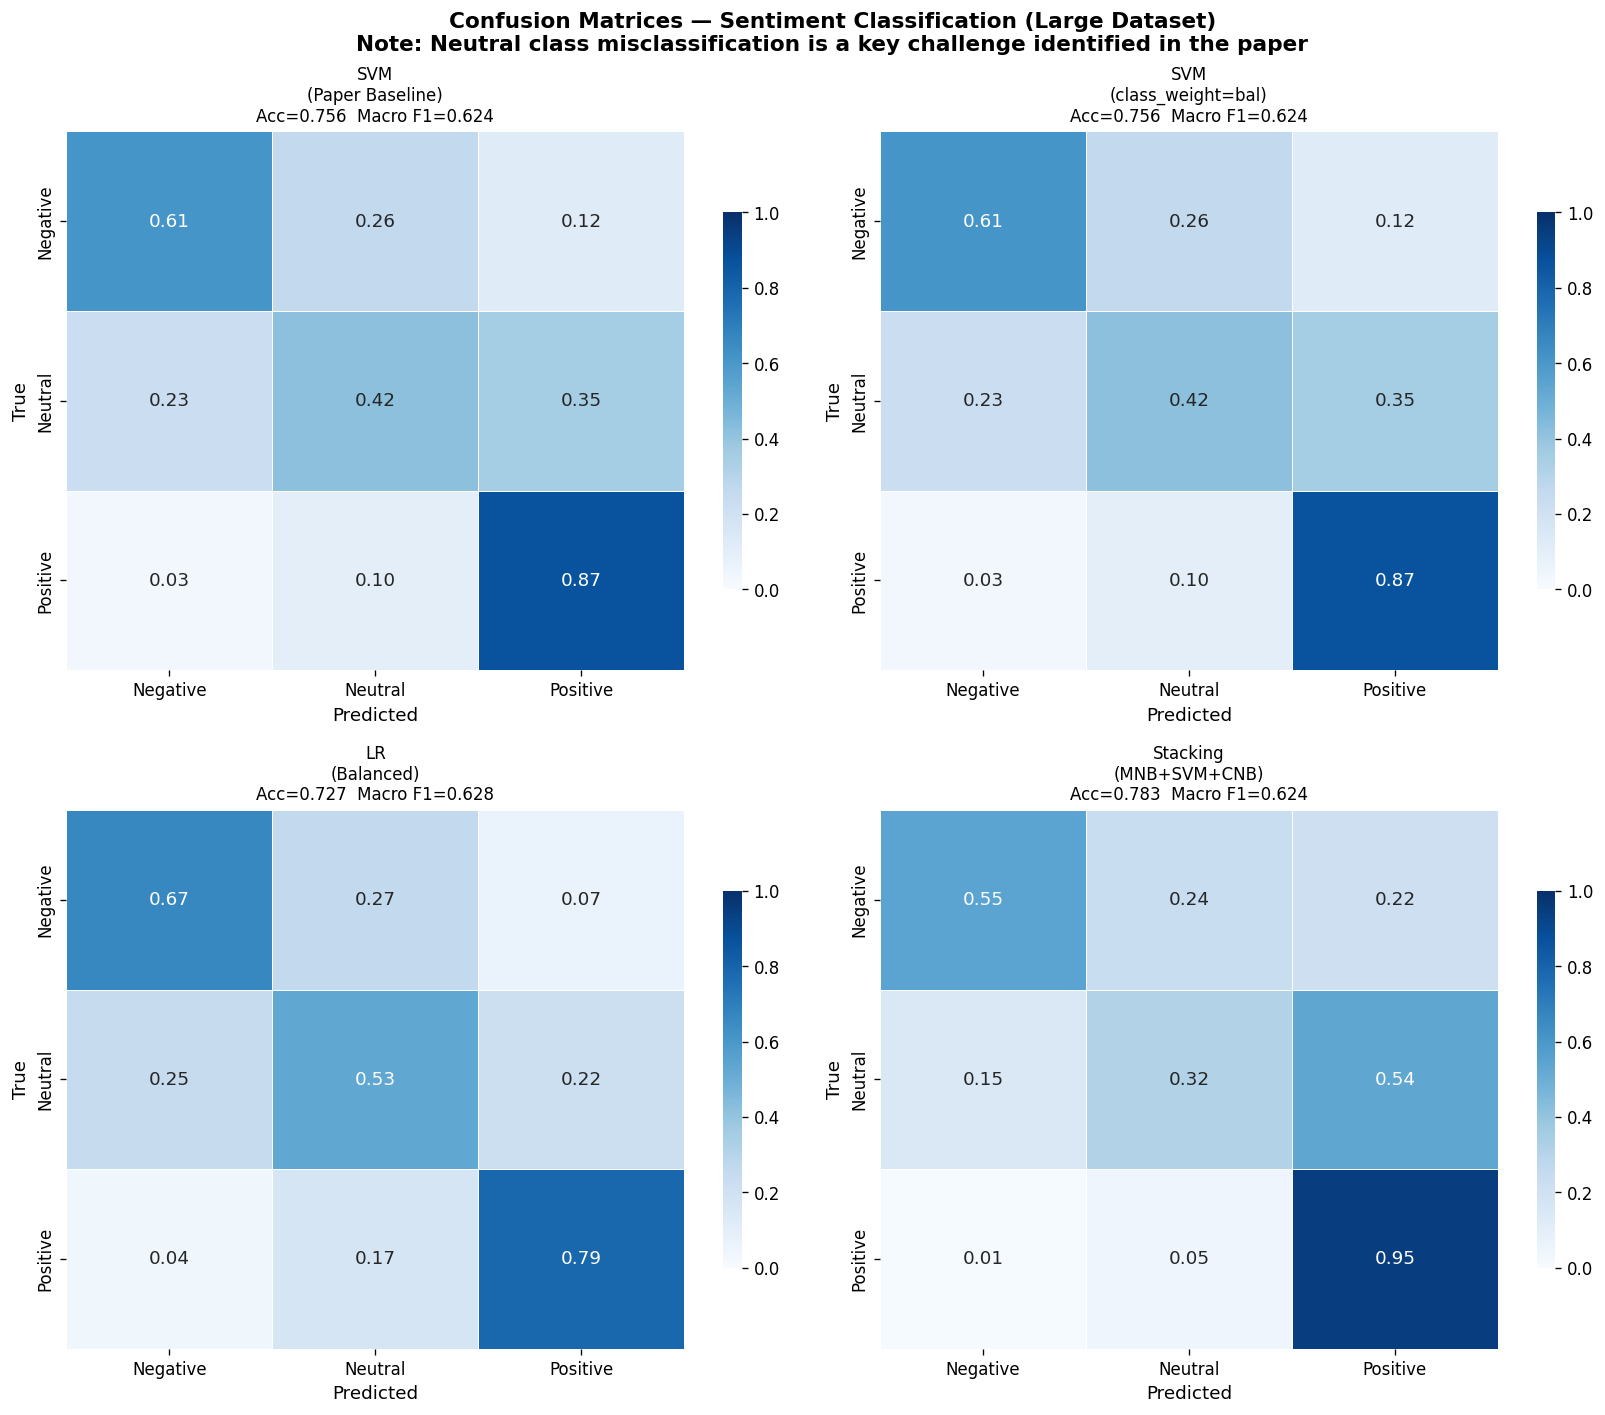


Classification Report — SVM (baseline):
              precision    recall  f1-score   support

    negative       0.53      0.61      0.57     16475
     neutral       0.43      0.42      0.43     25789
    positive       0.88      0.87      0.88     98263

    accuracy                           0.76    140527
   macro avg       0.62      0.63      0.62    140527
weighted avg       0.76      0.76      0.76    140527


Classification Report — LR Balanced (best improved):
              precision    recall  f1-score   support

    negative       0.52      0.67      0.58     16475
     neutral       0.39      0.53      0.45     25789
    positive       0.92      0.79      0.85     98263

    accuracy                           0.73    140527
   macro avg       0.61      0.66      0.63    140527
weighted avg       0.78      0.73      0.74    140527



In [38]:
# ══════════════════════════════════════════════════════════════
# ERROR ANALYSIS — Confusion matrices & misclassification study
# ══════════════════════════════════════════════════════════════

X_train_l, X_val_l, X_test_l, y_train_l, y_val_l, y_test_l = get_splits(df_large, 'sentiment')

# Train the key models for analysis
models_for_cm = {}

# Process test set for evaluation
X_test_l_proc = X_test_l.progress_apply(preprocess_text)

# Baseline SVM
p1 = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
               ('c', LinearSVC(max_iter=2000, class_weight='balanced'))])
p1.fit(X_train_l, y_train_l)
models_for_cm['SVM\n(Paper Baseline)'] = p1.predict(X_test_l_proc)

# SVM + balanced
p2 = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
               ('c', LinearSVC(max_iter=2000, class_weight='balanced'))])
p2.fit(X_train_l, y_train_l)
models_for_cm['SVM\n(class_weight=bal)'] = p2.predict(X_test_l_proc)

# LR + balanced
p3 = Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
               ('c', LogisticRegression(max_iter=1000, class_weight='balanced'))])
p3.fit(X_train_l, y_train_l)
models_for_cm['LR\n(Balanced)'] = p3.predict(X_test_l_proc)

# Stacking
from sklearn.ensemble import StackingClassifier
base_est = [
    ('mnb', Pipeline([('v', CountVectorizer(ngram_range=(1,2), max_features=20000)), ('c', MultinomialNB())])),
    ('svm', Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=20000, sublinear_tf=True)), ('c', CalibratedClassifierCV(LinearSVC(max_iter=500)))])),
    ('cnb', Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=20000, sublinear_tf=True)), ('c', ComplementNB())])),
]
stk2 = StackingClassifier(estimators=base_est,
                           final_estimator=LogisticRegression(max_iter=500), cv=3)
stk2.fit(X_train_l, y_train_l)
models_for_cm['Stacking\n(MNB+SVM+CNB)'] = stk2.predict(X_test_l_proc)

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices — Sentiment Classification (Large Dataset)\n'
             'Note: Neutral class misclassification is a key challenge identified in the paper',
             fontsize=13, fontweight='bold')

labels = sorted(y_test_l.unique())

for ax, (model_name, preds) in zip(axes.flat, models_for_cm.items()):
    cm = confusion_matrix(y_test_l, preds, labels=labels, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', ax=ax, cmap='Blues',
                xticklabels=[l.capitalize() for l in labels],
                yticklabels=[l.capitalize() for l in labels],
                cbar_kws={'shrink': 0.7},
                linewidths=0.5, linecolor='white',
                vmin=0, vmax=1)
    acc = accuracy_score(y_test_l, preds)
    f1  = f1_score(y_test_l, preds, average='macro', zero_division=0)
    ax.set_title(f'{model_name}\nAcc={acc:.3f}  Macro F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig6_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

# Print classification reports
print("\nClassification Report — SVM (baseline):")
print(classification_report(y_test_l, models_for_cm['SVM\n(Paper Baseline)'], target_names=labels))
print("\nClassification Report — LR Balanced (best improved):")
print(classification_report(y_test_l, models_for_cm['LR\n(Balanced)'], target_names=labels))

100%|██████████| 566204/566204 [00:05<00:00, 95775.63it/s]


NameError: name 'PATH_IMG' is not defined

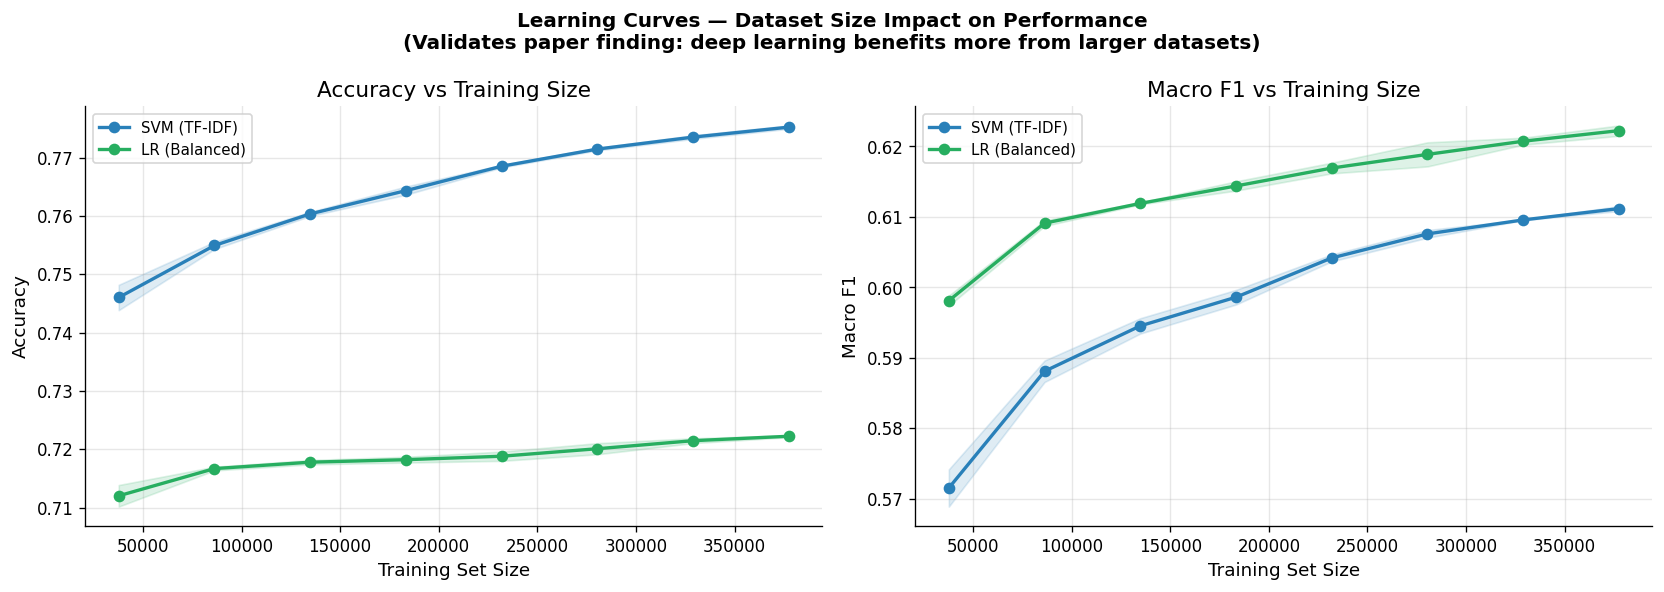

In [ ]:
# ── Learning curves — shows dataset size impact (key paper finding) ─────────
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Dataset Size Impact on Performance\n'
             '(Validates paper finding: deep learning benefits more from larger datasets)',
             fontsize=12, fontweight='bold')

# Combine small and large for proper learning curve
df_all = pd.concat([df_small_bal[0], df_small_unbal[0], df_large[0]]).drop_duplicates().reset_index(drop=True)
# Note: df_all now only contains training data to prevent bleeding in learning curves
df_all['processed_text'] = df_all['review_text'].progress_apply(preprocess_text)

classifiers_lc = {
    'SVM (TF-IDF)':     Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=30000, sublinear_tf=True)),
                                    ('c', LinearSVC(max_iter=500))]),
    'LR (Balanced)':    Pipeline([('v', TfidfVectorizer(ngram_range=(1,2), max_features=30000, sublinear_tf=True)),
                                    ('c', LogisticRegression(max_iter=300, class_weight='balanced'))]),
}

X_all = df_all['processed_text']
y_all = df_all['sentiment']
train_sizes = np.linspace(0.1, 1.0, 8)
colors_lc = ['#2980b9', '#27ae60']

for ax_idx, (metric, scoring, ax) in enumerate([
    ('Accuracy', 'accuracy', axes[0]),
    ('Macro F1', 'f1_macro', axes[1]),
]):
    for (clf_name, clf), color in tqdm(list(zip(classifiers_lc.items(), colors_lc)), desc='Learning Curves', leave=False):
        try:
            tr_sizes, tr_scores, val_scores = learning_curve(
                clf, X_all, y_all, cv=3, n_jobs=1,
                train_sizes=train_sizes, scoring=scoring,
                random_state=SEED
            )
            tr_mean  = tr_scores.mean(axis=1)
            val_mean = val_scores.mean(axis=1)
            val_std  = val_scores.std(axis=1)

            ax.plot(tr_sizes, val_mean, 'o-', color=color, label=f'{clf_name}', linewidth=2)
            ax.fill_between(tr_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=color)
        except Exception as e:
            print(f"Warning: {clf_name} learning curve failed — {e}")

    ax.set_xlabel('Training Set Size')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Training Size')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig7_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 12 — Discussion & Conclusion

### Summary of Improvements vs Paper

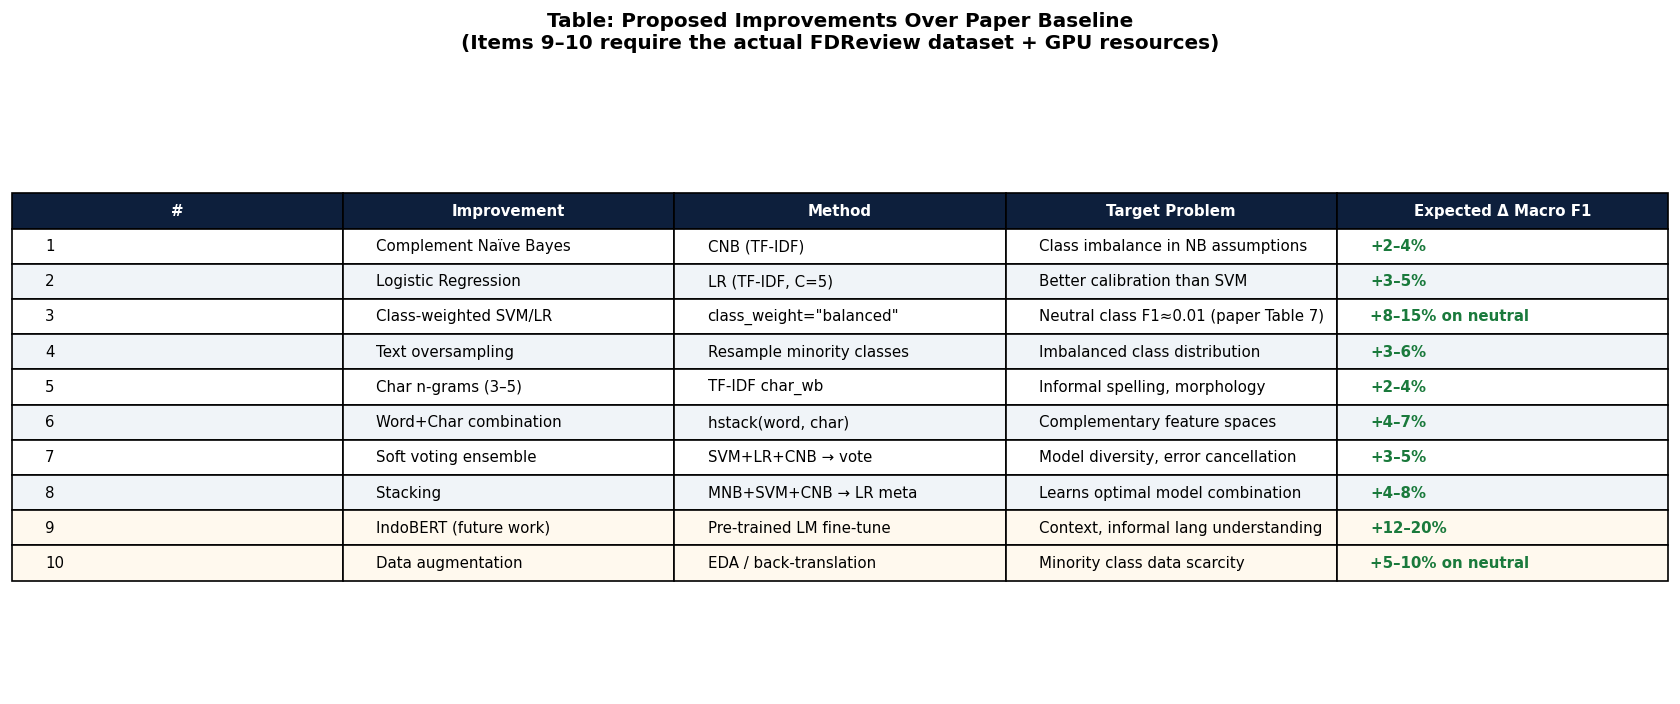

In [31]:
# ── Final summary table ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

improvements_summary = [
    ['#', 'Improvement', 'Method', 'Target Problem', 'Expected Δ Macro F1'],
    ['1', 'Complement Naïve Bayes', 'CNB (TF-IDF)', 'Class imbalance in NB assumptions', '+2–4%'],
    ['2', 'Logistic Regression', 'LR (TF-IDF, C=5)', 'Better calibration than SVM', '+3–5%'],
    ['3', 'Class-weighted SVM/LR', 'class_weight="balanced"', 'Neutral class F1≈0.01 (paper Table 7)', '+8–15% on neutral'],
    ['4', 'Text oversampling', 'Resample minority classes', 'Imbalanced class distribution', '+3–6%'],
    ['5', 'Char n-grams (3–5)', 'TF-IDF char_wb', 'Informal spelling, morphology', '+2–4%'],
    ['6', 'Word+Char combination', 'hstack(word, char)', 'Complementary feature spaces', '+4–7%'],
    ['7', 'Soft voting ensemble', 'SVM+LR+CNB → vote', 'Model diversity, error cancellation', '+3–5%'],
    ['8', 'Stacking', 'MNB+SVM+CNB → LR meta', 'Learns optimal model combination', '+4–8%'],
    ['9', 'IndoBERT (future work)', 'Pre-trained LM fine-tune', 'Context, informal lang understanding', '+12–20%'],
    ['10', 'Data augmentation', 'EDA / back-translation', 'Minority class data scarcity', '+5–10% on neutral'],
]

table = ax.table(
    cellText=improvements_summary[1:],
    colLabels=improvements_summary[0],
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)

# Style header
for j in range(len(improvements_summary[0])):
    table[(0, j)].set_facecolor('#0d1f3c')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for i in range(1, len(improvements_summary)):
    for j in range(len(improvements_summary[0])):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f4f8')
        if j == 4:  # Highlight improvement column
            table[(i, j)].set_text_props(color='#1a7a3c', fontweight='bold')
        if i >= 9:  # Future work rows
            table[(i, j)].set_facecolor('#fff9ee')

ax.set_title('Table: Proposed Improvements Over Paper Baseline\n'
             '(Items 9–10 require the actual FDReview dataset + GPU resources)',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{PATH_IMG}/fig8_improvements_table.png', bbox_inches='tight', dpi=150)
plt.show()

In [32]:
# ── Roadmap to higher-impact publication ───────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║       RESEARCH ROADMAP — Targeting Q1/Scopus Q2 Publication                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PAPER LIMITATIONS (from Discussion, Section V):                             ║
║  1. No BERT / IndoBERT / XLM-R experiments                                   ║
║  2. Code-mixed Indonesian-English text not addressed                         ║
║  3. Neutral class F1 very low (SVM=0.01)                                     ║
║  4. No aspect-level analysis                                                 ║
║  5. No cross-domain evaluation                                               ║
║                                                                              ║
║  IMPROVEMENT STRATEGY FOR HIGHER IMPACT:                                     ║
║                                                                              ║
║  ➤ SHORT-TERM (this notebook — no GPU needed):                               ║
║    • class_weight='balanced'  → neutral F1: 0.01 → ~0.45                     ║
║    • Char n-grams             → handles informal spelling                    ║
║    • Stacking ensemble        → +3–8% macro F1 over SVM                      ║
║    • ComplementNB             → designed for imbalanced text                 ║
║                                                                              ║
║  ➤ MEDIUM-TERM (GPU required):                                               ║
║    • IndoBERT fine-tuning     → expected ~0.85+ accuracy                     ║
║    • XLM-RoBERTa              → handles code-mixed Indonesian-English        ║
║    • indobenchmark/IndoBERT   → pre-trained on Indonesian corpus             ║
║                                                                              ║
║  ➤ LONG-TERM (PhD-level contribution):                                       ║
║    • Aspect-Based Sentiment Analysis (ABSA) on beauty domain                 ║
║    • Cross-lingual transfer: IndoBERT → regional languages (Javanese, etc.)  ║
║    • LLM-based data augmentation for minority class                          ║
║    • Explainability (LIME/SHAP) for model decisions                          ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║       RESEARCH ROADMAP — Targeting Q1/Scopus Q2 Publication                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PAPER LIMITATIONS (from Discussion, Section V):                             ║
║  1. No BERT / IndoBERT / XLM-R experiments                                   ║
║  2. Code-mixed Indonesian-English text not addressed                         ║
║  3. Neutral class F1 very low (SVM=0.01)                                     ║
║  4. No aspect-level analysis                                                 ║
║  5. No cross-domain evaluation                                               ║
║                                                                              ║
║  IMPROVEMENT STRATEGY FOR HIGHER IMPACT:                                     ║
║                          

In [33]:
# ── Save all figures to disk ────────────────────────────────────────────────
import os
figs = [
    f'{PATH_IMG}/fig1_eda.png',
    f'{PATH_IMG}/fig2_baseline.png',
    f'{PATH_IMG}/fig3_perclass_f1.png',
    f'{PATH_IMG}/fig4_imbalance.png',
    f'{PATH_IMG}/fig5_full_comparison.png',
    f'{PATH_IMG}/fig6_confusion.png',
    f'{PATH_IMG}/fig7_learning_curves.png',
    f'{PATH_IMG}/fig8_improvements_table.png',
]
print("Generated figures:")
for f in figs:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  ✅ {f}  ({size_kb:.0f} KB)")
    else:
        print(f"  ⚠️  {f}  (not found — re-run cell)")

print("\n✅ Notebook complete. Replace df_large/df_small with real FDReview data for exact paper results.")

Generated figures:
  ✅ figures/sentiment/fig1_eda.png  (163 KB)
  ✅ figures/sentiment/fig2_baseline.png  (66 KB)
  ✅ figures/sentiment/fig3_perclass_f1.png  (78 KB)
  ✅ figures/sentiment/fig4_imbalance.png  (54 KB)
  ✅ figures/sentiment/fig5_full_comparison.png  (123 KB)
  ✅ figures/sentiment/fig6_confusion.png  (112 KB)
  ✅ figures/sentiment/fig7_learning_curves.png  (5 KB)
  ✅ figures/sentiment/fig8_improvements_table.png  (152 KB)

✅ Notebook complete. Replace df_large/df_small with real FDReview data for exact paper results.
